![Illustration agricole](../agriculture.png)

# Rapport v2 - analyse amont des datasets agricoles

Ce rapport synthétise les données disponibles avant toute étape d'exploitation avancée. Il cherche à répondre à quatre questions :

- quelles sources sont suffisamment propres pour porter l'analyse ;
- quels facteurs semblent associés au rendement dans le dataset agronomique détaillé ;
- quelle profondeur historique est réellement disponible dans les fichiers annuels ;
- quelles précautions faut-il documenter avant de passer à la suite du projet.

La version est volontairement plus courte que le premier rapport : moins de graphiques descriptifs, davantage de graphiques utiles à la décision.

## Résumé exécutif

Deux familles de données coexistent dans le projet et ne doivent pas être mélangées sans précaution.

`crop_yield.csv` est un dataset agronomique très lisible, équilibré et probablement simulé ou fortement préparé. Il est utile pour expliquer les relations entre pluie, température, fertilisation, irrigation, météo, sol et rendement. Il contient toutefois des rendements négatifs, à retirer pour une lecture métier cohérente.

Les fichiers historiques `yield.csv`, `rainfall.csv`, `pesticides.csv` et `temp.csv` portent une information annuelle par pays. `yield.csv` est la meilleure table de base car il contient le rendement par pays, culture et année. Les autres fichiers enrichissent cette base à la maille pays + année, mais avec des limites : pluie parfois manquante, température à agréger, pesticides non disponibles pour tous les pays.

L'analyse recommande de conserver les rendements historiques récents comme information prioritaire, puis d'ajouter pluie, température et pesticides comme contexte annuel. Les variables de parcelle disponibles dans `crop_yield.csv`, notamment irrigation et fertilisation, restent utiles pour interpréter des scénarios locaux, mais elles ne sont pas directement présentes dans les fichiers historiques.

## 1. Chargement et conventions

Les chemins sont lus depuis `config/project_paths.yaml` afin de garder le rapport aligné avec le reste du projet. Les graphiques sont limités à quelques vues de synthèse.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "scripts" / "project_config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Cache local pour éviter les écritures hors workspace lors du rendu Matplotlib.
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "artifacts" / ".matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(PROJECT_ROOT / "artifacts" / ".cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scripts.project_config import load_preparation_config

config = load_preparation_config()
MIN_YEAR = int(config.get("MIN_YEAR", 1990))

AGRI_CROP_YIELD_PATH = config["AGRI_CROP_YIELD_PATH"]
YIELD_PATH = config["YIELD_PATH"]
RAINFALL_PATH = config["RAINFALL_PATH"]
PESTICIDES_PATH = config["PESTICIDES_PATH"]
TEMP_PATH = config["TEMP_PATH"]
YIELD_DF_AUDIT_PATH = config["YIELD_DF_AUDIT_PATH"]
DATASET_PATH = config["DATASET_PATH"]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

In [2]:
agri_raw = pd.read_csv(AGRI_CROP_YIELD_PATH)
yield_raw = pd.read_csv(YIELD_PATH)
rainfall_raw = pd.read_csv(RAINFALL_PATH).rename(columns={" Area": "Area"})
pesticides_raw = pd.read_csv(PESTICIDES_PATH)
temp_raw = pd.read_csv(TEMP_PATH).rename(columns={"country": "Area", "year": "Year"})
yield_df_audit = pd.read_csv(YIELD_DF_AUDIT_PATH)
consolidated = pd.read_csv(DATASET_PATH)

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Dataset consolidé disponible : {DATASET_PATH.relative_to(PROJECT_ROOT)}")

Racine projet : /Users/steph/Code/Python/Jupyter/OCR_Projet12
Dataset consolidé disponible : data/dataset_consolide.csv


## 2. Périmètre des sources

Cette première synthèse remplace plusieurs graphiques génériques. Elle donne la taille, la période couverte, la qualité de base et la clé naturelle de chaque fichier.

In [3]:
def source_overview(name, df, *, year_col=None, key_cols=None, role=""):
    overview = {
        "source": name,
        "role": role,
        "lignes": len(df),
        "colonnes": df.shape[1],
        "pct_nan": round(df.isna().mean().mean() * 100, 2),
        "doublons_lignes": int(df.duplicated().sum()),
        "cle_naturelle": " + ".join(key_cols) if key_cols else "-",
        "doublons_sur_cle": np.nan,
        "annee_min": np.nan,
        "annee_max": np.nan,
    }
    if year_col and year_col in df.columns:
        years = pd.to_numeric(df[year_col], errors="coerce")
        overview["annee_min"] = int(years.min()) if years.notna().any() else np.nan
        overview["annee_max"] = int(years.max()) if years.notna().any() else np.nan
    if key_cols and all(col in df.columns for col in key_cols):
        overview["doublons_sur_cle"] = int(df.duplicated(subset=key_cols).sum())
    return overview

sources = pd.DataFrame([
    source_overview(
        "crop_yield.csv",
        agri_raw,
        key_cols=None,
        role="facteurs agronomiques détaillés",
    ),
    source_overview(
        "yield.csv",
        yield_raw,
        year_col="Year",
        key_cols=["Area", "Item", "Year"],
        role="rendement par pays, culture et année",
    ),
    source_overview(
        "rainfall.csv",
        rainfall_raw,
        year_col="Year",
        key_cols=["Area", "Year"],
        role="pluie annuelle par pays",
    ),
    source_overview(
        "pesticides.csv",
        pesticides_raw,
        year_col="Year",
        key_cols=["Area", "Year"],
        role="intrants pesticides par pays",
    ),
    source_overview(
        "temp.csv",
        temp_raw,
        year_col="Year",
        key_cols=["Area", "Year"],
        role="température moyenne par pays",
    ),
    source_overview(
        "yield_df.csv",
        yield_df_audit,
        year_col="Year",
        key_cols=["Area", "Item", "Year"],
        role="fichier déjà enrichi, utile en audit",
    ),
    source_overview(
        "dataset_consolide.csv",
        consolidated,
        year_col="year",
        key_cols=["area", "crop", "year"],
        role="base consolidée produite par préparation",
    ),
])

display(sources)

,source,role,lignes,colonnes,pct_nan,doublons_lignes,cle_naturelle,doublons_sur_cle,annee_min,annee_max
0,crop_yield.csv,facteurs agronomiques détaillés,1000000,10,0.000,0,-,NaN,NaN,NaN
1,yield.csv,"rendement par pays, culture et année",56717,12,0.000,0,Area + Item + Year,0.000,"1,961.000","2,016.000"
2,rainfall.csv,pluie annuelle par pays,6727,3,3.840,0,Area + Year,0.000,"1,985.000","2,017.000"
3,pesticides.csv,intrants pesticides par pays,4349,7,0.000,0,Area + Year,0.000,"1,990.000","2,016.000"
4,temp.csv,température moyenne par pays,71311,3,1.190,6958,Area + Year,"42,797.000","1,743.000","2,013.000"
5,yield_df.csv,"fichier déjà enrichi, utile en audit",28242,8,0.000,0,Area + Item + Year,"15,112.000","1,990.000","2,013.000"
6,dataset_consolide.csv,base consolidée produite par préparation,29367,7,12.540,0,area + crop + year,0.000,"1,990.000","2,016.000"


### Couverture temporelle utile

La couverture annuelle montre que les sources ne portent pas le même volume d'information. Le rendement est profond et riche, tandis que les variables de contexte sont disponibles à une maille plus agrégée.

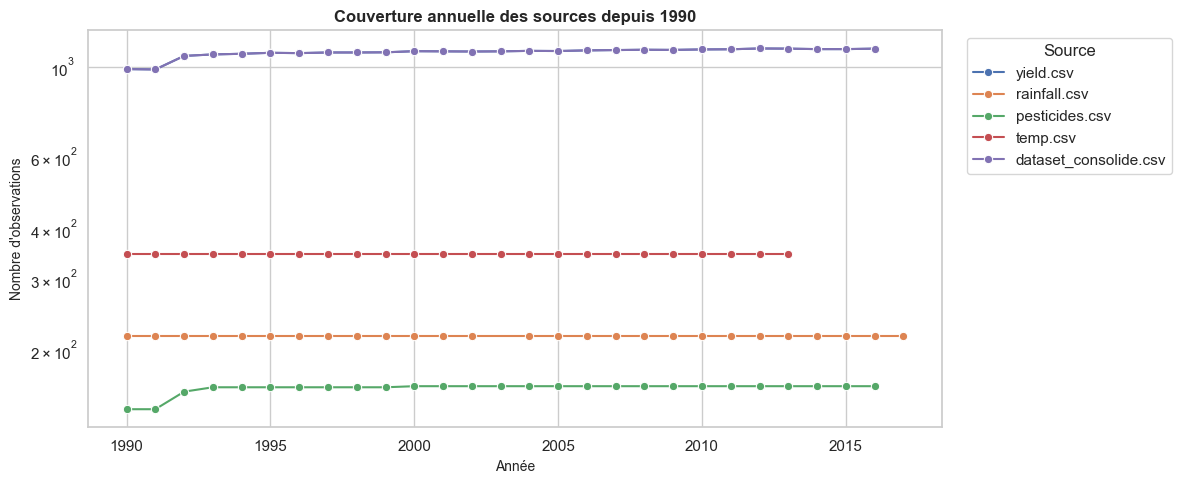

In [4]:
def yearly_count(df, year_col, source, min_year=MIN_YEAR):
    years = pd.to_numeric(df[year_col], errors="coerce")
    tmp = df.assign(_year=years).loc[lambda d: d["_year"].ge(min_year)]
    return tmp.groupby("_year").size().rename("observations").reset_index().assign(source=source)

coverage_counts = pd.concat(
    [
        yearly_count(yield_raw, "Year", "yield.csv"),
        yearly_count(rainfall_raw, "Year", "rainfall.csv"),
        yearly_count(pesticides_raw, "Year", "pesticides.csv"),
        yearly_count(temp_raw, "Year", "temp.csv"),
        yearly_count(consolidated.rename(columns={"year": "Year"}), "Year", "dataset_consolide.csv"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=coverage_counts, x="_year", y="observations", hue="source", marker="o", ax=ax)
ax.set_title("Couverture annuelle des sources depuis 1990")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre d'observations")
ax.set_yscale("log")
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. Lecture du dataset agronomique détaillé `crop_yield.csv`

Ce dataset est utile pour comprendre des relations métier simples : pluie, température, irrigation, fertilisation, météo et sol. Il est cependant très équilibré sur les catégories, ce qui suggère une source simulée ou déjà fortement construite. On l'utilise donc comme support d'interprétation, pas comme preuve historique mondiale.

In [5]:
agri = agri_raw.rename(
    columns={
        "Region": "region",
        "Soil_Type": "soil_type",
        "Crop": "crop",
        "Rainfall_mm": "rainfall_mm",
        "Temperature_Celsius": "temperature_celsius",
        "Fertilizer_Used": "fertilizer_used",
        "Irrigation_Used": "irrigation_used",
        "Weather_Condition": "weather_condition",
        "Days_to_Harvest": "days_to_harvest",
        "Yield_tons_per_hectare": "yield_tons_per_hectare",
    }
)

negative_yields = int((agri["yield_tons_per_hectare"] < 0).sum())
agri_clean = agri.loc[agri["yield_tons_per_hectare"].ge(0)].copy()

agri_summary = pd.DataFrame(
    {
        "indicateur": [
            "lignes_initiales",
            "lignes_apres_retrait_rendements_negatifs",
            "rendements_negatifs_retires",
            "rendement_moyen_t_ha",
            "rendement_median_t_ha",
            "rendement_min_t_ha_apres_filtre",
            "rendement_max_t_ha_apres_filtre",
        ],
        "valeur": [
            len(agri),
            len(agri_clean),
            negative_yields,
            agri_clean["yield_tons_per_hectare"].mean(),
            agri_clean["yield_tons_per_hectare"].median(),
            agri_clean["yield_tons_per_hectare"].min(),
            agri_clean["yield_tons_per_hectare"].max(),
        ],
    }
)

display(agri_summary)

,indicateur,valeur
0,lignes_initiales,"1,000,000.000"
1,lignes_apres_retrait_rendements_negatifs,"999,769.000"
2,rendements_negatifs_retires,231.000
3,rendement_moyen_t_ha,4.651
4,rendement_median_t_ha,4.652
5,rendement_min_t_ha_apres_filtre,0.000
6,rendement_max_t_ha_apres_filtre,9.963


### Facteurs associés au rendement

Plutôt que d'afficher toutes les distributions, on mesure ici l'amplitude de rendement moyen associée à chaque facteur. Cette vue indique quels facteurs méritent d'être gardés dans l'analyse explicative.

,facteur,lecture,amplitude_t_ha,rendement_min_moyen,rendement_max_moyen
0,Pluie,écart entre quartiles extrêmes,3.366,2.967,6.333
3,Fertilisation,écart entre modalités,1.498,3.901,5.400
4,Irrigation,écart entre modalités,1.198,4.052,5.250
1,Température,écart entre quartiles extrêmes,0.378,4.462,4.840
2,Jours avant récolte,écart entre quartiles extrêmes,0.017,4.641,4.658
7,Culture,écart entre modalités,0.012,4.643,4.655
8,Région,écart entre modalités,0.009,4.647,4.655
6,Type de sol,écart entre modalités,0.008,4.646,4.654
5,Météo,écart entre modalités,0.005,4.648,4.653


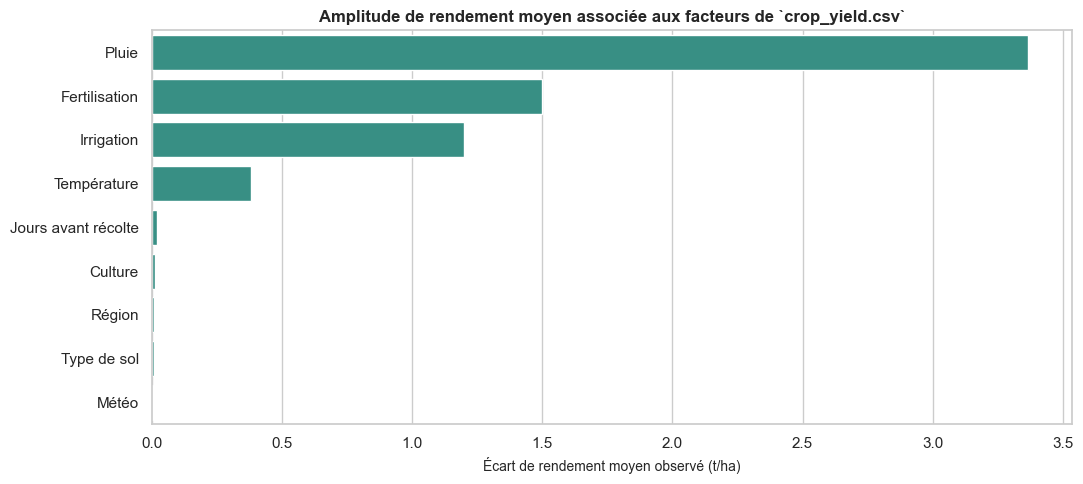

In [6]:
def quartile_amplitude(df, column, label):
    bins = pd.qcut(df[column], q=4, duplicates="drop")
    means = df.groupby(bins, observed=True)["yield_tons_per_hectare"].mean()
    return {
        "facteur": label,
        "lecture": "écart entre quartiles extrêmes",
        "amplitude_t_ha": float(means.max() - means.min()),
        "rendement_min_moyen": float(means.min()),
        "rendement_max_moyen": float(means.max()),
    }


def category_amplitude(df, column, label):
    means = df.groupby(column, observed=True)["yield_tons_per_hectare"].mean()
    return {
        "facteur": label,
        "lecture": "écart entre modalités",
        "amplitude_t_ha": float(means.max() - means.min()),
        "rendement_min_moyen": float(means.min()),
        "rendement_max_moyen": float(means.max()),
    }

factor_effects = pd.DataFrame(
    [
        quartile_amplitude(agri_clean, "rainfall_mm", "Pluie"),
        quartile_amplitude(agri_clean, "temperature_celsius", "Température"),
        quartile_amplitude(agri_clean, "days_to_harvest", "Jours avant récolte"),
        category_amplitude(agri_clean, "fertilizer_used", "Fertilisation"),
        category_amplitude(agri_clean, "irrigation_used", "Irrigation"),
        category_amplitude(agri_clean, "weather_condition", "Météo"),
        category_amplitude(agri_clean, "soil_type", "Type de sol"),
        category_amplitude(agri_clean, "crop", "Culture"),
        category_amplitude(agri_clean, "region", "Région"),
    ]
).sort_values("amplitude_t_ha", ascending=False)

display(factor_effects)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=factor_effects, x="amplitude_t_ha", y="facteur", color="#2a9d8f", ax=ax)
ax.set_title("Amplitude de rendement moyen associée aux facteurs de `crop_yield.csv`")
ax.set_xlabel("Écart de rendement moyen observé (t/ha)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Interaction pluie x température

La pluie domine la lecture du rendement dans ce fichier. La température ajoute une nuance, mais l'écart entre zones sèches et zones humides reste le signal le plus visible.

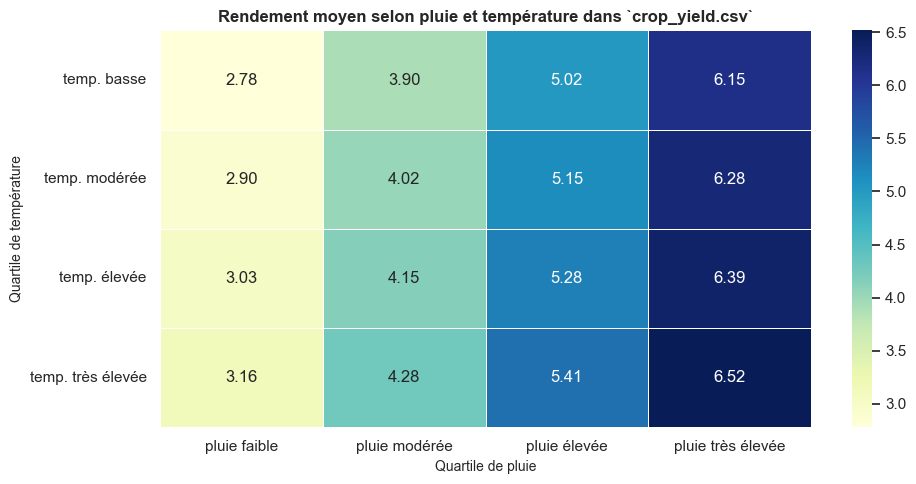

In [7]:
interaction_df = agri_clean.copy()
interaction_df["quartile_pluie"] = pd.qcut(
    interaction_df["rainfall_mm"], q=4, labels=["pluie faible", "pluie modérée", "pluie élevée", "pluie très élevée"]
)
interaction_df["quartile_temperature"] = pd.qcut(
    interaction_df["temperature_celsius"], q=4, labels=["temp. basse", "temp. modérée", "temp. élevée", "temp. très élevée"]
)

rain_temp_yield = interaction_df.pivot_table(
    index="quartile_temperature",
    columns="quartile_pluie",
    values="yield_tons_per_hectare",
    aggfunc="mean",
    observed=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(rain_temp_yield, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Rendement moyen selon pluie et température dans `crop_yield.csv`")
ax.set_xlabel("Quartile de pluie")
ax.set_ylabel("Quartile de température")
plt.tight_layout()
plt.show()

## 4. Construction logique de la base historique

Pour les fichiers historiques, la décision importante porte sur les clés de jointure. Le rendement est à la maille pays + culture + année. La pluie, la température et les pesticides sont à la maille pays + année. Elles peuvent donc enrichir chaque culture observée dans un pays et une année donnés, mais elles ne décrivent pas une parcelle individuelle.

In [8]:
yield_recent = yield_raw.loc[yield_raw["Year"].ge(MIN_YEAR)].copy()
yield_recent["target_yield_t_ha"] = yield_recent["Value"] / 10_000

rainfall = rainfall_raw.copy()
rainfall["average_rain_fall_mm_per_year"] = pd.to_numeric(
    rainfall["average_rain_fall_mm_per_year"], errors="coerce"
)
rainfall_recent = rainfall.loc[rainfall["Year"].ge(MIN_YEAR)].copy()

pesticides_recent = pesticides_raw.loc[pesticides_raw["Year"].ge(MIN_YEAR)].copy()

temp_recent = temp_raw.loc[temp_raw["Year"].ge(MIN_YEAR)].copy()
temp_aggregated = (
    temp_recent.groupby(["Area", "Year"], as_index=False)["avg_temp"].mean()
)

join_quality = pd.DataFrame(
    [
        {
            "source": "yield.csv",
            "cle": "Area + Item + Year",
            "role": "table de base du rendement",
            "lignes": len(yield_recent),
            "doublons_sur_cle": int(yield_recent.duplicated(["Area", "Item", "Year"]).sum()),
            "valeurs_manquantes": int(yield_recent.isna().sum().sum()),
        },
        {
            "source": "rainfall.csv",
            "cle": "Area + Year",
            "role": "contexte pluie",
            "lignes": len(rainfall_recent),
            "doublons_sur_cle": int(rainfall_recent.duplicated(["Area", "Year"]).sum()),
            "valeurs_manquantes": int(rainfall_recent.isna().sum().sum()),
        },
        {
            "source": "pesticides.csv",
            "cle": "Area + Year",
            "role": "contexte intrants",
            "lignes": len(pesticides_recent),
            "doublons_sur_cle": int(pesticides_recent.duplicated(["Area", "Year"]).sum()),
            "valeurs_manquantes": int(pesticides_recent.isna().sum().sum()),
        },
        {
            "source": "temp.csv agrégé",
            "cle": "Area + Year",
            "role": "contexte température",
            "lignes": len(temp_aggregated),
            "doublons_sur_cle": int(temp_aggregated.duplicated(["Area", "Year"]).sum()),
            "valeurs_manquantes": int(temp_aggregated.isna().sum().sum()),
        },
        {
            "source": "dataset_consolide.csv",
            "cle": "area + crop + year",
            "role": "résultat de préparation",
            "lignes": len(consolidated),
            "doublons_sur_cle": int(consolidated.duplicated(["area", "crop", "year"]).sum()),
            "valeurs_manquantes": int(consolidated.isna().sum().sum()),
        },
    ]
)

display(join_quality)

,source,cle,role,lignes,doublons_sur_cle,valeurs_manquantes
0,yield.csv,Area + Item + Year,table de base du rendement,29367,0,0
1,rainfall.csv,Area + Year,contexte pluie,5859,0,677
2,pesticides.csv,Area + Year,contexte intrants,4349,0,0
3,temp.csv agrégé,Area + Year,contexte température,3288,0,0
4,dataset_consolide.csv,area + crop + year,résultat de préparation,29367,0,25779


### Couverture et manquants dans la base consolidée

Cette vue est plus utile qu'une série de graphiques par fichier : elle indique directement quelles années et quelles variables seront solides dans la base de travail.

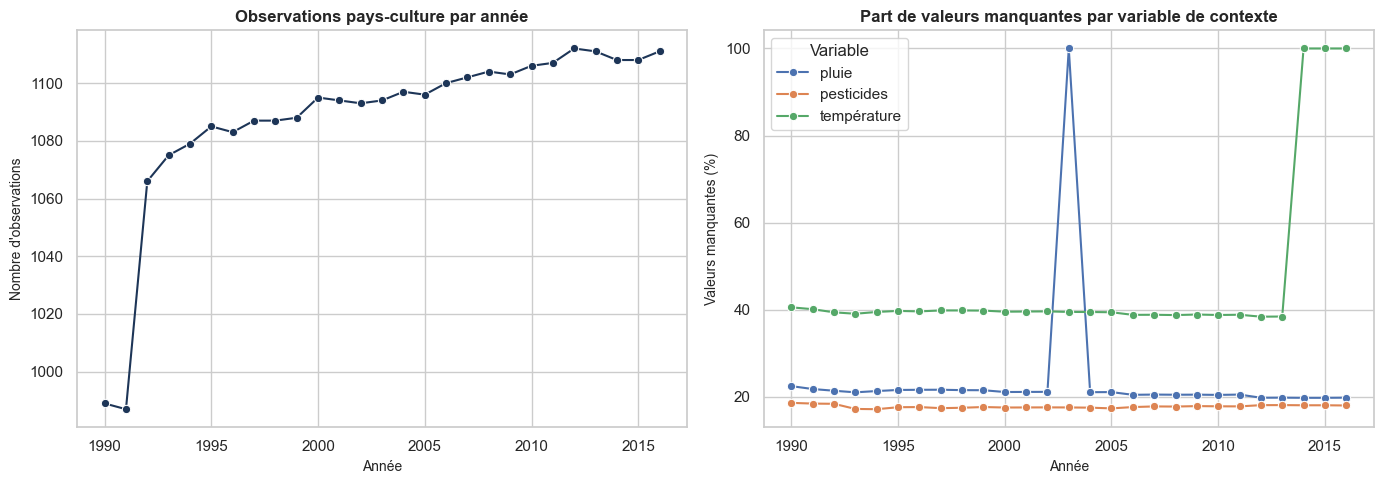

In [9]:
yearly_consolidated = (
    consolidated.groupby("year")
    .agg(
        observations=("target_yield_t_ha", "size"),
        pays=("area", "nunique"),
        cultures=("crop", "nunique"),
        pct_pluie_manquante=("average_rain_fall_mm_per_year", lambda s: s.isna().mean() * 100),
        pct_pesticides_manquants=("pesticides_tonnes", lambda s: s.isna().mean() * 100),
        pct_temperature_manquante=("avg_temp", lambda s: s.isna().mean() * 100),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=yearly_consolidated, x="year", y="observations", marker="o", ax=axes[0], color="#1d3557")
axes[0].set_title("Observations pays-culture par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre d'observations")

missing_long = yearly_consolidated.melt(
    id_vars="year",
    value_vars=["pct_pluie_manquante", "pct_pesticides_manquants", "pct_temperature_manquante"],
    var_name="variable",
    value_name="pct_manquant",
)
missing_long["variable"] = missing_long["variable"].replace(
    {
        "pct_pluie_manquante": "pluie",
        "pct_pesticides_manquants": "pesticides",
        "pct_temperature_manquante": "température",
    }
)
sns.lineplot(data=missing_long, x="year", y="pct_manquant", hue="variable", marker="o", ax=axes[1])
axes[1].set_title("Part de valeurs manquantes par variable de contexte")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Valeurs manquantes (%)")
axes[1].legend(title="Variable")
plt.tight_layout()
plt.show()

## 5. Continuité des rendements historiques

Le rendement agricole varie d'une année à l'autre, mais les séries pays-culture montrent aussi une forte continuité. Cette information est importante pour hiérarchiser les variables : avant d'interpréter pluie, température ou intrants, il faut vérifier si le rendement récent porte déjà une grande partie du niveau observé.

,comparaison,annee_reference,series_comparables,correlation,ecart_absolu_median_t_ha
0,2015 vs 2016,2015,1108,0.984,0.133
1,2014 vs 2016,2014,1108,0.969,0.233
2,2013 vs 2016,2013,1110,0.962,0.316
3,2011 vs 2016,2011,1098,0.960,0.375
4,2006 vs 2016,2006,1090,0.930,0.663


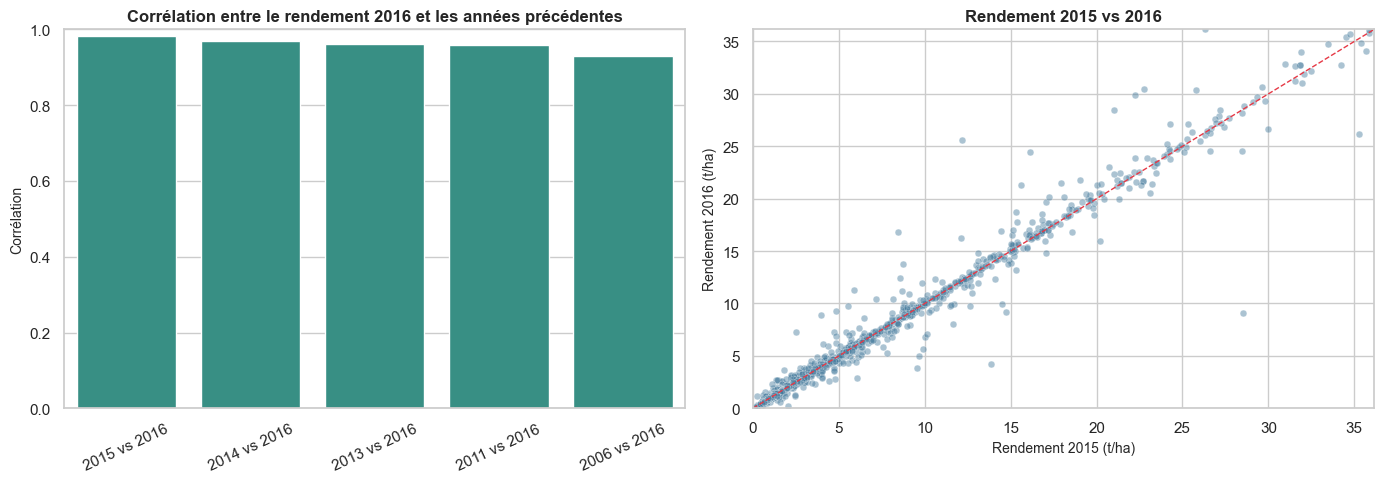

In [10]:
yield_wide = consolidated.pivot_table(
    index=["area", "crop"],
    columns="year",
    values="target_yield_t_ha",
    aggfunc="mean",
)
last_year = int(np.nanmax(consolidated["year"]))

lag_rows = []
for lag in [1, 2, 3, 5, 10]:
    previous_year = last_year - lag
    if previous_year not in yield_wide.columns or last_year not in yield_wide.columns:
        continue
    pair = yield_wide[[previous_year, last_year]].dropna()
    lag_rows.append(
        {
            "comparaison": f"{previous_year} vs {last_year}",
            "annee_reference": previous_year,
            "series_comparables": len(pair),
            "correlation": pair[previous_year].corr(pair[last_year]),
            "ecart_absolu_median_t_ha": (pair[last_year] - pair[previous_year]).abs().median(),
        }
    )
lag_table = pd.DataFrame(lag_rows)
display(lag_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=lag_table, x="comparaison", y="correlation", color="#2a9d8f", ax=axes[0])
axes[0].set_title(f"Corrélation entre le rendement {last_year} et les années précédentes")
axes[0].set_xlabel("")
axes[0].set_ylabel("Corrélation")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylim(0, 1)

previous_year = last_year - 1
scatter_pair = yield_wide[[previous_year, last_year]].dropna().sample(
    n=min(2_000, yield_wide[[previous_year, last_year]].dropna().shape[0]),
    random_state=42,
)
sns.scatterplot(data=scatter_pair, x=previous_year, y=last_year, alpha=0.45, s=24, ax=axes[1], color="#457b9d")
limit_max = float(np.nanpercentile(scatter_pair[[previous_year, last_year]].values, 99))
axes[1].plot([0, limit_max], [0, limit_max], linestyle="--", color="#e63946", linewidth=1)
axes[1].set_title(f"Rendement {previous_year} vs {last_year}")
axes[1].set_xlabel(f"Rendement {previous_year} (t/ha)")
axes[1].set_ylabel(f"Rendement {last_year} (t/ha)")
axes[1].set_xlim(0, limit_max)
axes[1].set_ylim(0, limit_max)
plt.tight_layout()
plt.show()

## 6. ACP sur les variables quantitatives de `crop_yield.csv`

L'ACP est utilisée comme outil de cadrage, pas comme fin en soi. On l'applique aux variables quantitatives explicatives disponibles dans `crop_yield.csv` : pluie, température et jours avant récolte. Le rendement est ensuite utilisé comme couleur de lecture sur le plan factoriel, afin de voir si les zones de rendement élevé se distinguent visuellement.

In [11]:
pca_features = ["rainfall_mm", "temperature_celsius", "days_to_harvest"]
pca_source = agri_clean[pca_features + ["yield_tons_per_hectare"]].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_source[pca_features])
pca = PCA(n_components=len(pca_features), random_state=42)
scores = pca.fit_transform(X_scaled)

pca_variance = pd.DataFrame(
    {
        "axe": [f"PC{i + 1}" for i in range(len(pca_features))],
        "variance_expliquee_pct": pca.explained_variance_ratio_ * 100,
        "variance_cumulee_pct": np.cumsum(pca.explained_variance_ratio_) * 100,
    }
)
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=pca_features,
    columns=[f"PC{i + 1}" for i in range(len(pca_features))],
)
pc1_contributions = pd.DataFrame(
    {
        "variable": pca_features,
        "contribution_PC1_pct": (pca.components_[0] ** 2 / np.sum(pca.components_[0] ** 2)) * 100,
    }
).sort_values("contribution_PC1_pct", ascending=False)

display(pca_variance)
display(loadings)
display(pc1_contributions)

,axe,variance_expliquee_pct,variance_cumulee_pct
0,PC1,33.424,33.424
1,PC2,33.340,66.763
2,PC3,33.237,100.000


,PC1,PC2,PC3
rainfall_mm,-0.693,-0.262,0.672
temperature_celsius,-0.104,0.958,0.265
days_to_harvest,0.715,-0.114,0.690


,variable,contribution_PC1_pct
2,days_to_harvest,50.987
0,rainfall_mm,47.929
1,temperature_celsius,1.084


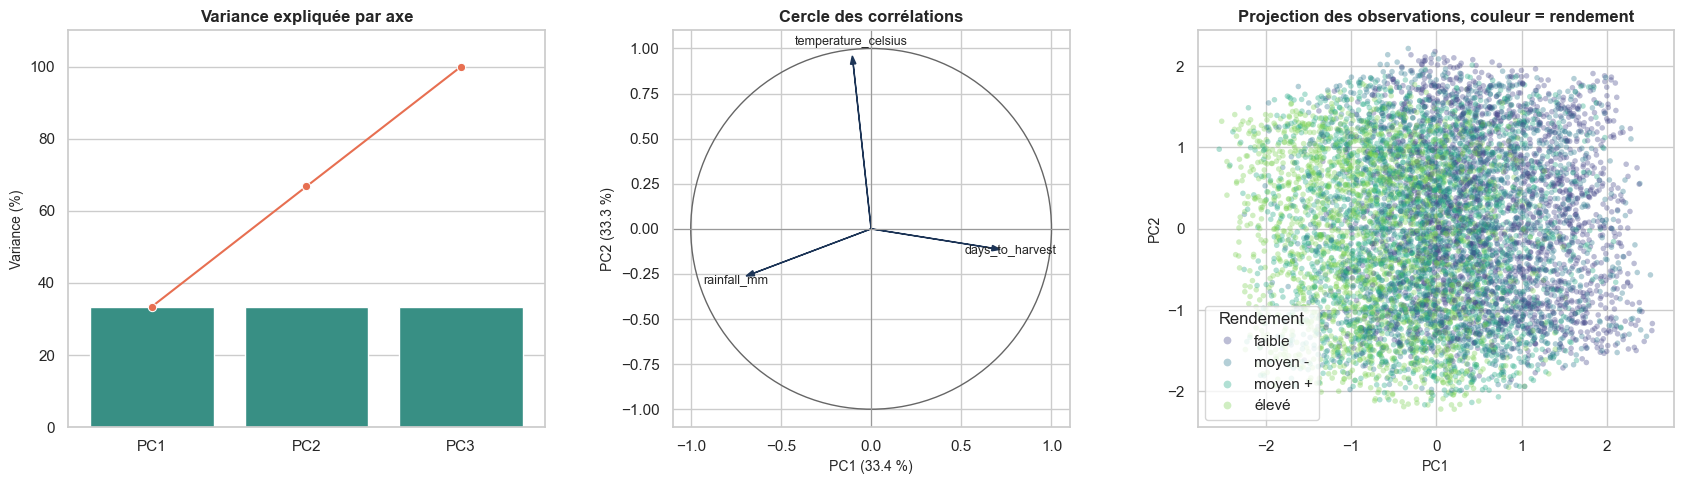

In [12]:
pca_plot = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"])
pca_plot["rendement_t_ha"] = pca_source["yield_tons_per_hectare"].to_numpy()
pca_plot["classe_rendement"] = pd.qcut(
    pca_plot["rendement_t_ha"],
    q=4,
    labels=["faible", "moyen -", "moyen +", "élevé"],
)
pca_sample = pca_plot.sample(n=min(8_000, len(pca_plot)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.barplot(data=pca_variance, x="axe", y="variance_expliquee_pct", color="#2a9d8f", ax=axes[0])
sns.lineplot(data=pca_variance, x="axe", y="variance_cumulee_pct", marker="o", color="#e76f51", ax=axes[0])
axes[0].set_title("Variance expliquée par axe")
axes[0].set_ylabel("Variance (%)")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 110)

circle = plt.Circle((0, 0), 1, color="#666666", fill=False, linewidth=1)
axes[1].add_artist(circle)
axes[1].axhline(0, color="#999999", linewidth=0.8)
axes[1].axvline(0, color="#999999", linewidth=0.8)
for feature in pca_features:
    x = loadings.loc[feature, "PC1"]
    y = loadings.loc[feature, "PC2"]
    axes[1].arrow(0, 0, x, y, head_width=0.03, length_includes_head=True, color="#1d3557")
    axes[1].text(x * 1.08, y * 1.08, feature, ha="center", va="center", fontsize=9)
axes[1].set_xlim(-1.1, 1.1)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_aspect("equal", "box")
axes[1].set_title("Cercle des corrélations")
axes[1].set_xlabel(f"PC1 ({pca_variance.loc[0, 'variance_expliquee_pct']:.1f} %)")
axes[1].set_ylabel(f"PC2 ({pca_variance.loc[1, 'variance_expliquee_pct']:.1f} %)")

sns.scatterplot(
    data=pca_sample,
    x="PC1",
    y="PC2",
    hue="classe_rendement",
    alpha=0.35,
    s=16,
    linewidth=0,
    ax=axes[2],
    palette="viridis",
)
axes[2].set_title("Projection des observations, couleur = rendement")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
axes[2].legend(title="Rendement", markerscale=1.4)

plt.tight_layout()
plt.show()

### Lecture de l'ACP

L'ACP confirme que les trois variables quantitatives de `crop_yield.csv` ne se résument pas toutes à un seul axe. La pluie porte une dimension très visible dans l'analyse, tandis que la température et les jours avant récolte apportent des informations complémentaires. La projection colorée par rendement doit être lue avec prudence : elle aide à visualiser des zones de rendement plus ou moins élevé, mais elle ne remplace pas les tableaux de relation entre facteurs et rendement.

## 7. Synthèse des choix de données

Les décisions proposées pour la suite du projet sont les suivantes :

- utiliser `yield.csv` comme source de référence du rendement, car sa clé naturelle `Area + Item + Year` est propre ;
- enrichir cette base par `rainfall.csv`, `pesticides.csv` et `temp.csv` à la maille `Area + Year` ;
- agréger `temp.csv` avant jointure, car il contient plusieurs lignes pour un même pays et une même année ;
- conserver les lignes de rendement même quand une variable de contexte manque, car supprimer massivement ces observations réduirait fortement la couverture ;
- traiter `yield_df.csv` comme un fichier d'audit, pas comme la source principale ;
- retirer les rendements négatifs de `crop_yield.csv` pour les analyses métier ;
- ne pas interpréter `crop_yield.csv` comme un historique mondial : ses catégories sont trop équilibrées pour cela ;
- documenter clairement l'absence de surface en hectares et l'absence d'irrigation réelle dans les fichiers historiques.

La recommandation principale est de produire un rapport court, centré sur la qualité, la couverture, les facteurs candidats et l'ACP. Les graphiques conservés doivent expliquer une décision de préparation ou une relation métier ; les distributions génériques peuvent rester en annexe si nécessaire.